# Интеллектуальная система мониторинга динамики стоимости образовательных услуг
*(на примере ЧОУ ВО «Московский университет имени С.Ю. Витте»)*

Данный ноутбук содержит этапы:
1. Загрузка и анализ датасета `data.csv`.
2. Визуализация динамики стоимости обучения.
3. Обучение моделей линейной регрессии по образовательным программам.
4. Прогноз стоимости обучения на будущие годы.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
%matplotlib inline


## Загрузка и первичный анализ данных

In [7]:
df = pd.read_csv('data.csv')
df.head()

,year,university,program,form,cost
0,2018,МУИВ,Экономика,очная,95000
1,2019,МУИВ,Экономика,очная,102000
2,2020,МУИВ,Экономика,очная,120000
3,2021,МУИВ,Экономика,очная,125000
4,2022,МУИВ,Экономика,очная,130000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   year        88 non-null     int64
 1   university  88 non-null     str  
 2   program     88 non-null     str  
 3   form        88 non-null     str  
 4   cost        88 non-null     int64
dtypes: int64(2), str(3)
memory usage: 3.6 KB


Ожидаемая структура датасета:

- `year` — год;
- `university` — наименование вуза;
- `program` — образовательная программа (направление подготовки);
- `form` — форма обучения (например, очная);
- `cost` — стоимость обучения в рублях.

## Базовый статистический анализ

In [9]:
df.describe(include='all')

,year,university,program,form,cost
count,88.000000,88,88,88,88.000000
unique,NaN,4,6,1,NaN
top,NaN,МУИВ,Экономика,очная,NaN
freq,NaN,48,16,88,NaN
mean,2021.500000,NaN,NaN,NaN,134022.727273
std,2.304419,NaN,NaN,NaN,23199.770744
min,2018.000000,NaN,NaN,NaN,85000.000000
25%,2019.750000,NaN,NaN,NaN,118000.000000
50%,2021.500000,NaN,NaN,NaN,133500.000000
75%,2023.250000,NaN,NaN,NaN,150500.000000


## Динамика стоимости обучения в МУИВ по программам

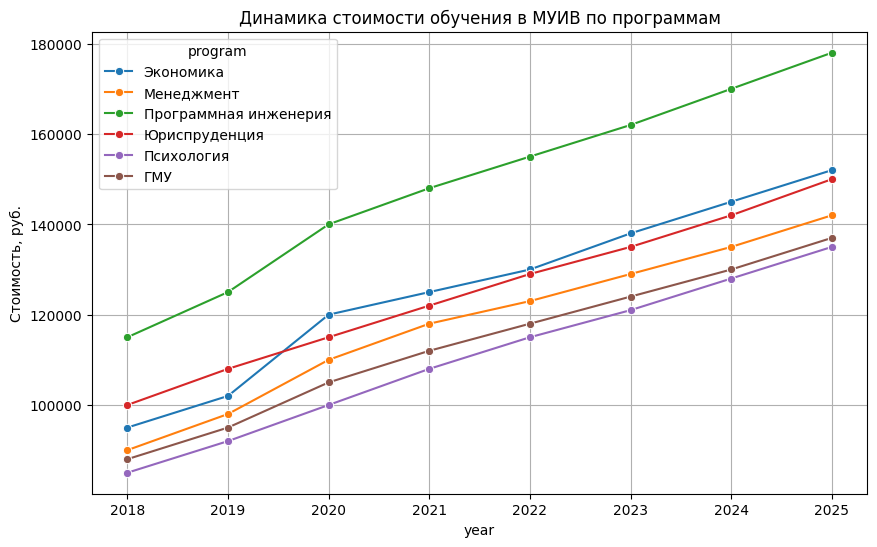

In [10]:
muiv = df[df['university'].str.contains('МУИВ')]
plt.figure(figsize=(10,6))
sns.lineplot(data=muiv, x='year', y='cost', hue='program', marker='o')
plt.title('Динамика стоимости обучения в МУИВ по программам')
plt.ylabel('Стоимость, руб.')
plt.grid(True)
plt.show()

## Сравнение стоимости обучения по программе «Экономика» между вузами

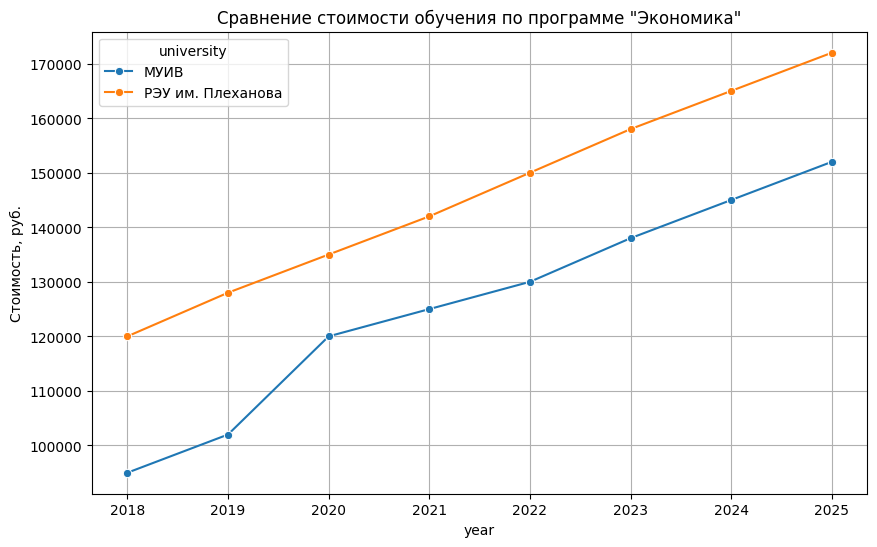

In [11]:
eco = df[df['program'] == 'Экономика']
plt.figure(figsize=(10,6))
sns.lineplot(data=eco, x='year', y='cost', hue='university', marker='o')
plt.title('Сравнение стоимости обучения по программе "Экономика"')
plt.ylabel('Стоимость, руб.')
plt.grid(True)
plt.show()

## Обучение моделей линейной регрессии по образовательным программам

In [12]:
models = {}
for program in df['program'].unique():
    df_prog = df[df['program'] == program]
    X = df_prog[['year']]
    y = df_prog['cost']
    model = LinearRegression()
    model.fit(X, y)
    models[program] = model
    print(f'Программа: {program}, коэффициент наклона: {model.coef_[0]:.2f}, сдвиг: {model.intercept_:.2f}')

Программа: Экономика, коэффициент наклона: 7732.14, сдвиг: -15494464.29
Программа: Менеджмент, коэффициент наклона: 7196.43, сдвиг: -14417017.86
Программа: Программная инженерия, коэффициент наклона: 8166.67, сдвиг: -16356166.67
Программа: Юриспруденция, коэффициент наклона: 7267.86, сдвиг: -14553785.71
Программа: Психология, коэффициент наклона: 7142.86, сдвиг: -14328785.71
Программа: ГМУ, коэффициент наклона: 6946.43, сдвиг: -13917892.86


## Функция для прогноза стоимости обучения

In [13]:
def predict_cost(program, year):
    if program not in models:
        raise ValueError(f'Нет модели для программы: {program}')
    model = models[program]
    X = np.array([[year]])
    return float(model.predict(X)[0])

predict_cost('Экономика', 2026)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


170857.1428571418

## Прогноз стоимости обучения на несколько лет вперёд

In [14]:
future_years = list(range(2025, 2031))
program = 'Экономика'
preds = []
for y in future_years:
    preds.append({'year': y, 'program': program, 'pred_cost': predict_cost(program, y)})
pred_df = pd.DataFrame(preds)
pred_df

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-p

,year,program,pred_cost
0,2025,Экономика,163125.000000
1,2026,Экономика,170857.142857
2,2027,Экономика,178589.285714
3,2028,Экономика,186321.428571
4,2029,Экономика,194053.571429
5,2030,Экономика,201785.714286


## Визуализация фактических и прогнозных значений для выбранной программы

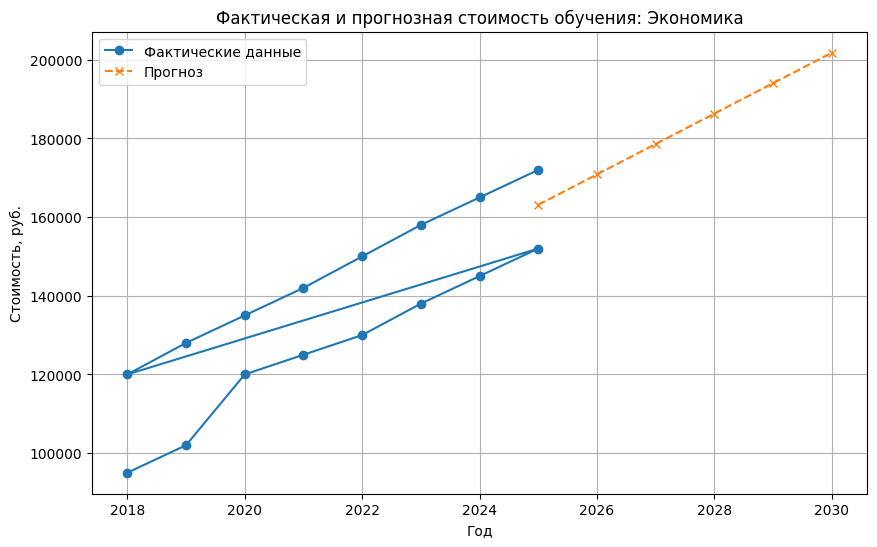

In [15]:
prog = 'Экономика'
df_prog = df[df['program'] == prog]

plt.figure(figsize=(10,6))
plt.plot(df_prog['year'], df_prog['cost'], marker='o', label='Фактические данные')
plt.plot(pred_df['year'], pred_df['pred_cost'], marker='x', linestyle='--', label='Прогноз')
plt.title(f'Фактическая и прогнозная стоимость обучения: {prog}')
plt.xlabel('Год')
plt.ylabel('Стоимость, руб.')
plt.grid(True)
plt.legend()
plt.show()

## Выводы

- Построены модели линейной регрессии по образовательным программам.
- Выполнен анализ динамики стоимости обучения в МУИВ и вузах‑аналогах.
- Реализована функция прогноза стоимости обучения на основе исторических данных.
- Полученные результаты могут быть использованы в интеллектуальной системе мониторинга динамики стоимости образовательных услуг.